In [1]:
# Import the core libraries used for image processing, model building, training, visualization, and splitting the dataset.

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

2026-06-02 13:34:50.716126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780407290.931239      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780407290.994944      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780407291.518202      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780407291.518240      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780407291.518243      58 computation_placer.cc:177] computation placer alr

In [3]:
# Load the training dataset from the NumPy file and print how many samples are available.

data = np.load("/kaggle/input/datasets/shubhamrathore850/train-data/Part 1- Train data - images.npy", allow_pickle=True)

print("Total Images :", len(data))

Total Images : 409


In [5]:
# This cell inspects the shapes of images already stored in the `images` list. Run it only after the preprocessing cell that creates `images`.

for i, img in enumerate(images):
    print(i, img.shape)

0 (256, 256, 3)
1 (256, 256, 4)
2 (256, 256, 3)
3 (256, 256, 4)
4 (256, 256, 3)
5 (256, 256, 3)
6 (256, 256, 3)
7 (256, 256, 3)
8 (256, 256, 3)
9 (256, 256, 3)
10 (256, 256, 3)
11 (256, 256, 3)
12 (256, 256, 3)
13 (256, 256, 3)
14 (256, 256, 3)
15 (256, 256, 3)
16 (256, 256, 3)
17 (256, 256, 3)
18 (256, 256, 3)
19 (256, 256, 3)
20 (256, 256, 3)
21 (256, 256, 3)
22 (256, 256, 3)
23 (256, 256, 3)
24 (256, 256, 3)
25 (256, 256, 3)
26 (256, 256, 3)
27 (256, 256, 3)
28 (256, 256, 3)
29 (256, 256, 3)
30 (256, 256, 3)
31 (256, 256, 3)
32 (256, 256, 3)
33 (256, 256, 3)
34 (256, 256, 3)
35 (256, 256, 3)
36 (256, 256, 3)
37 (256, 256, 3)
38 (256, 256, 3)
39 (256, 256, 3)
40 (256, 256, 3)
41 (256, 256, 4)
42 (256, 256, 3)
43 (256, 256, 3)
44 (256, 256, 3)
45 (256, 256, 3)
46 (256, 256, 3)
47 (256, 256, 3)
48 (256, 256, 3)
49 (256, 256, 4)
50 (256, 256, 3)
51 (256, 256, 3)
52 (256, 256, 3)
53 (256, 256, 3)
54 (256, 256, 3)
55 (256, 256, 3)
56 (256, 256, 3)
57 (256, 256, 3)
58 (256, 256, 3)
59 (256

In [7]:
# Set the target image size used throughout preprocessing and model training.
IMG_SIZE = 256

# Lists that will store the processed images and their corresponding masks.
images = []
masks = []

# Loop through each training sample in the dataset.
for sample in data:

    # Each sample contains the raw image and the face annotations.
    image = sample[0]
    annotation = sample[1]

    # -------------------------
    # IMAGE FIX
    # -------------------------

    # Resize the image to the common training size.
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # If the image is grayscale, convert it to RGB.
    if len(image.shape) == 2:
        image = cv2.cvtColor(image.astype(np.uint8),
                             cv2.COLOR_GRAY2RGB)

    # If the image has 4 channels (RGBA), convert it to RGB.
    elif len(image.shape) == 3 and image.shape[2] == 4:
        image = cv2.cvtColor(image.astype(np.uint8),
                             cv2.COLOR_RGBA2RGB)

    # Keep only the first 3 channels to make sure the image is RGB.
    image = image[:, :, :3]

    # -------------------------
    # MASK CREATION
    # -------------------------

    # Create an empty binary mask with the same height and width as the image.
    h, w = image.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # Draw a filled rectangle on the mask for each annotated face.
    for face in annotation:

        p1 = face['points'][0]
        p2 = face['points'][1]

        # Convert normalized annotation coordinates into pixel coordinates.
        x1 = int(p1['x'] * w)
        y1 = int(p1['y'] * h)
        x2 = int(p2['x'] * w)
        y2 = int(p2['y'] * h)

        # Mark the face region as 1 in the mask.
        mask[y1:y2, x1:x2] = 1

    # Resize the mask with nearest-neighbor interpolation to keep it binary.
    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Store processed image and mask.
    images.append(image)
    masks.append(mask)

# -------------------------
# CONVERT TO NUMPY ARRAYS
# -------------------------

# Normalize image values to 0-1.
images = np.stack(images).astype(np.float32) / 255.0

# Convert masks to NumPy arrays and add the channel dimension.
masks = np.stack(masks).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

# Print final shapes to confirm preprocessing worked.
print("Images Shape :", images.shape)
print("Masks Shape :", masks.shape)


Images Shape : (409, 256, 256, 3)
Masks Shape : (409, 256, 256, 1)


In [8]:
print(images.shape)
print(masks.shape)

print(images.dtype)
print(masks.dtype)

(409, 256, 256, 3)
(409, 256, 256, 1)
float32
float32


In [9]:
# Data augmentation pipeline to improve generalization during training.
augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1)
])


I0000 00:00:1780407711.087811      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780407711.093678      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
# Split the dataset into training and validation sets.

X_train, X_val, y_train, y_val = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(327, 256, 256, 3)
(82, 256, 256, 3)


In [11]:
# Dice coefficient measures overlap between the predicted mask and the true mask.
def dice_coefficient(y_true, y_pred):

    # Small constant prevents division by zero.
    smooth = 1e-6

    # Flatten tensors so the overlap is calculated over all pixels.
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    # Calculate the intersection between predicted and actual pixels.
    intersection = tf.reduce_sum(y_true * y_pred)

    # Dice score formula.
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


In [12]:
# Dice loss is defined as 1 minus the Dice coefficient.
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


In [14]:
# Build a U-Net style segmentation model using MobileNetV2 as the encoder.
def build_model():

    # Pretrained MobileNetV2 acts as the feature extractor (encoder).
    encoder = MobileNetV2(
        input_shape=(256,256,3),
        include_top=False,
        weights='imagenet'
    )

    # Skip connections capture feature maps from earlier encoder layers.
    skip1 = encoder.get_layer("block_1_expand_relu").output
    skip2 = encoder.get_layer("block_3_expand_relu").output
    skip3 = encoder.get_layer("block_6_expand_relu").output
    skip4 = encoder.get_layer("block_13_expand_relu").output
    bridge = encoder.get_layer("block_16_project").output

    # Decoder: upsample and concatenate with skip connections for fine details.
    x = Conv2DTranspose(512, 2, strides=2, padding='same')(bridge)
    x = Concatenate()([x, skip4])
    x = Conv2D(512, 3, padding='same', activation='relu')(x)

    x = Conv2DTranspose(256, 2, strides=2, padding='same')(x)
    x = Concatenate()([x, skip3])
    x = Conv2D(256, 3, padding='same', activation='relu')(x)

    x = Conv2DTranspose(128, 2, strides=2, padding='same')(x)
    x = Concatenate()([x, skip2])
    x = Conv2D(128, 3, padding='same', activation='relu')(x)

    x = Conv2DTranspose(64, 2, strides=2, padding='same')(x)
    x = Concatenate()([x, skip1])
    x = Conv2D(64, 3, padding='same', activation='relu')(x)

    # Final upsampling layer before generating the mask.
    x = Conv2DTranspose(32, 2, strides=2, padding='same')(x)

    # Sigmoid output gives pixel-wise probabilities for face mask prediction.
    output = Conv2D(1, 1, activation='sigmoid')(x)

    # Create the final Keras model.
    model = Model(encoder.input, output)
    return model


In [15]:
# Create the model and print its architecture summary.

model = build_model()

model.summary()

/tmp/ipykernel_58/3546592573.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 9,646,849 (36.80 MB)

 Trainable params: 9,615,937 (36.68 MB)

 Non-trainable params: 30,912 (120.75 KB)

In [16]:
# Save the best-performing model during training.
checkpoint = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True
)

# Stop training early if validation performance stops improving.
early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)


In [17]:
# Compile the model with Adam optimizer, Dice loss, and Dice metric.
model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coefficient]
)


In [19]:
# Train the model on the training set and validate on the validation set.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=8,
    callbacks=[
        checkpoint,
        early_stop
    ]
)


Epoch 1/10


I0000 00:00:1780407816.172648     144 service.cc:152] XLA service 0x7a03f8014760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780407816.172706     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780407816.172713     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780407820.307579     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-02 13:43:49.854556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:43:50.002788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:43:50.138445: E external/local_xl

40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - dice_coefficient: 0.2248 - loss: 0.7752

2026-06-02 13:44:38.964618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:44:39.118251: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:44:39.254281: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:44:41.455865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:44:41.686821: E external/local_xla/xla/stream_

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coefficient: 0.2257 - loss: 0.7744   

2026-06-02 13:45:29.162084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:45:29.298244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:45:31.260272: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:45:31.487670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:45:32.357069: E external/local_xla/xla/stream_

41/41 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - dice_coefficient: 0.2594 - loss: 0.7417 - val_dice_coefficient: 0.5494 - val_loss: 0.4446
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - dice_coefficient: 0.6383 - loss: 0.3617

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - dice_coefficient: 0.6413 - loss: 0.3590 - val_dice_coefficient: 0.5710 - val_loss: 0.4418
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - dice_coefficient: 0.6809 - loss: 0.3191

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - dice_coefficient: 0.6798 - loss: 0.3205 - val_dice_coefficient: 0.5901 - val_loss: 0.4198
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - dice_coefficient: 0.6682 - loss: 0.3319 - val_dice_coefficient: 0.4937 - val_loss: 0.5083
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - dice_coefficient: 0.6705 - loss: 0.3293 - val_dice_coefficient: 0.3746 - val_loss: 0.6312
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - dice_coefficient: 0.5806 - loss: 0.4195 - val_dice_coefficient: 0.4536 - val_loss: 0.5466


In [20]:
# Evaluate the trained model on the validation set.
loss, dice = model.evaluate(
    X_val,
    y_val
)

print("Loss :", loss)
print("Dice Score :", dice)


2026-06-02 13:47:33.229578: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:47:33.367079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:47:43.877314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:47:44.056800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - dice_coefficient: 0.5926 - loss: 0.4074

2026-06-02 13:47:56.579357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:47:56.716144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:00.617577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:00.869007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:03.607706: E external/local_xla/xla/stream_

3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - dice_coefficient: 0.5837 - loss: 0.4136
Loss : 0.41363784670829773
Dice Score : 0.5836532115936279


In [21]:
# Predict the mask for the first validation image.
prediction = model.predict(
    X_val[:1]
)


2026-06-02 13:48:38.918524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:39.052388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:39.975347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 13:48:40.178829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


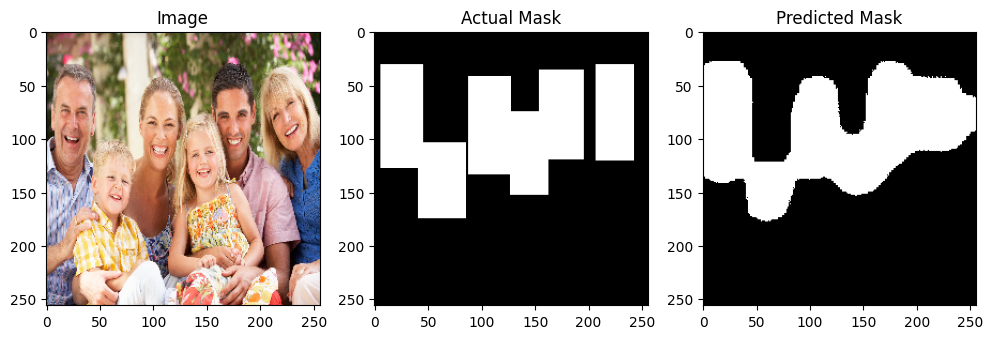

In [22]:
# Visualize the original image, ground-truth mask, and predicted mask.
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[0])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(
    y_val[0].squeeze(),
    cmap='gray'
)
plt.title("Actual Mask")

plt.subplot(1,3,3)
plt.imshow(
    prediction[0].squeeze(),
    cmap='gray'
)
plt.title("Predicted Mask")

plt.show()
